### Loading the Datasets

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.mkdir("exported_charts")

plt.style.use("ggplot")

df = pd.read_csv("merged_players.csv", parse_dates=['born_date', 'debut_date', 'last_date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25070 entries, 0 to 25069
Data columns (total 67 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   player_id                    25070 non-null  int64         
 1   player_name                  25070 non-null  str           
 2   player_full_name             25070 non-null  str           
 3   first_name                   25070 non-null  str           
 4   last_name                    25070 non-null  str           
 5   born_date                    25070 non-null  datetime64[us]
 6   debut_date                   25070 non-null  datetime64[us]
 7   debut_age                    25070 non-null  int64         
 8   last_date                    25070 non-null  datetime64[us]
 9   last_age                     25070 non-null  int64         
 10  height                       25070 non-null  int64         
 11  weight                       25070 non-null  float64

C:\Users\MEE\AppData\Local\Temp\ipykernel_11896\1879024179.py:10: DtypeWarning: Columns (0: is_finals) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_players.csv", parse_dates=['born_date', 'debut_date', 'last_date'])


### Q> Which Teams have played the most games?

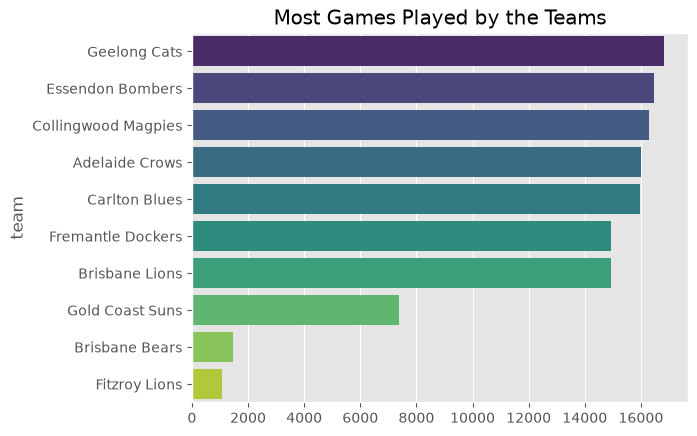

<Figure size 640x480 with 0 Axes>

In [5]:
plt.title("Most Games Played by the Teams")
most_games_played = df.groupby('team')['games_played'].sum().head(10).sort_values(ascending=False)
sns.barplot(x=most_games_played.values, y=most_games_played.index, hue=most_games_played.index, legend=False, palette='viridis')
plt.show()
plt.savefig('exported_charts/Team with most games.png')



#### Observataion:
- Geelong Cats more than 16000 games.
- Fitzroy Lions and Brisbane bears played the least games.
#### Insight:
- Geelong cats have been long establihsed as they have most games plays which shows consistensy in the league which can attract sponspers as they might have the greatest fan base

### Q> What is the distribution of player ages (last_age)?

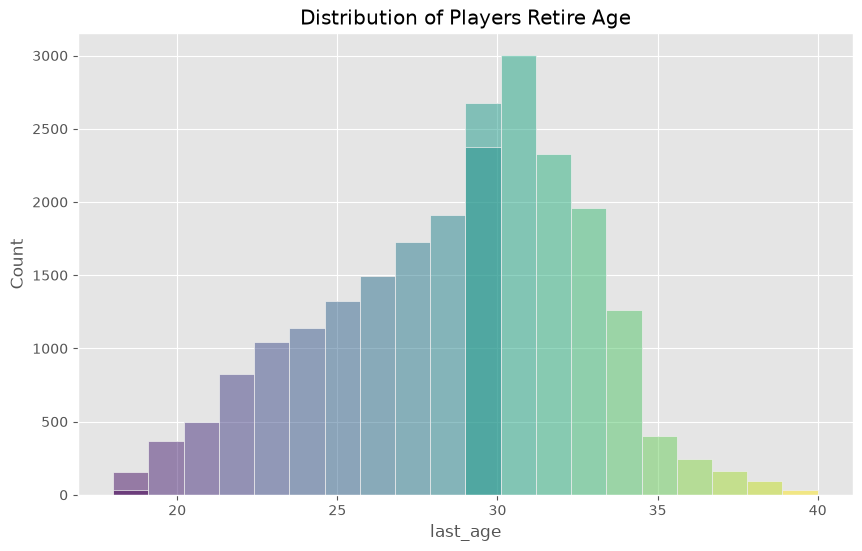

<Figure size 640x480 with 0 Axes>

In [4]:
plt.figure(figsize=(10,6))
plt.title("Distribution of Players Retire Age")
sns.histplot(data=df, bins=20, palette='viridis', x='last_age', hue='last_age', legend=False)
plt.show()
plt.savefig('exported_charts/Distribution of players age.png')

#### Observation:
- Most players can be seen retiring between age of 27-33
- Some players can been seen retiring at early start of career while some late end of career

#### Insight:
- This data can be used to draw players contract as most players decide to retire when they hit the age of 30.

### Q> Which player team have the highest number of players? 

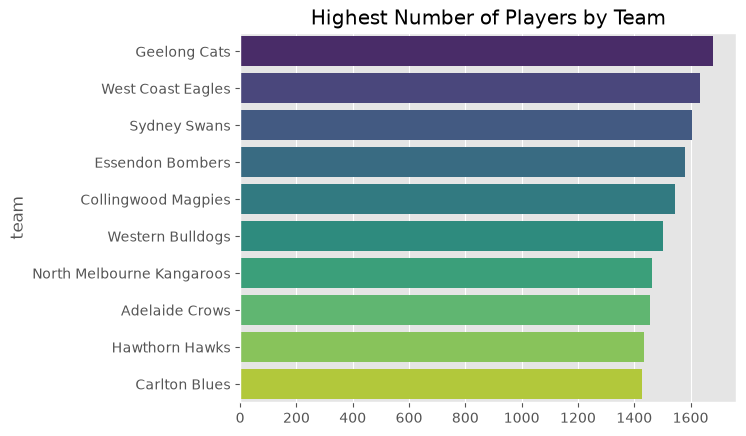

<Figure size 640x480 with 0 Axes>

In [6]:
plt.title("Highest Number of Players by Team")
players_per_team = df['team'].value_counts().head(10)
sns.barplot(x=players_per_team.values, y=players_per_team.index, palette='viridis', legend=False, hue=players_per_team.index)
plt.show()
plt.savefig('exported_charts/Highest numbers of players.png')

#### Observation:
- As Geelong cats have been the oldest team, it have had the most players in theer entire run more than 1600.
- on the contrary Cariton blue is just behind with 1400 players.

#### Insight:
- Geelong Cats has been the most dominant team of the league with far more fetched networking they hire the new potential players

### Q> How does player weight vary across different teams?

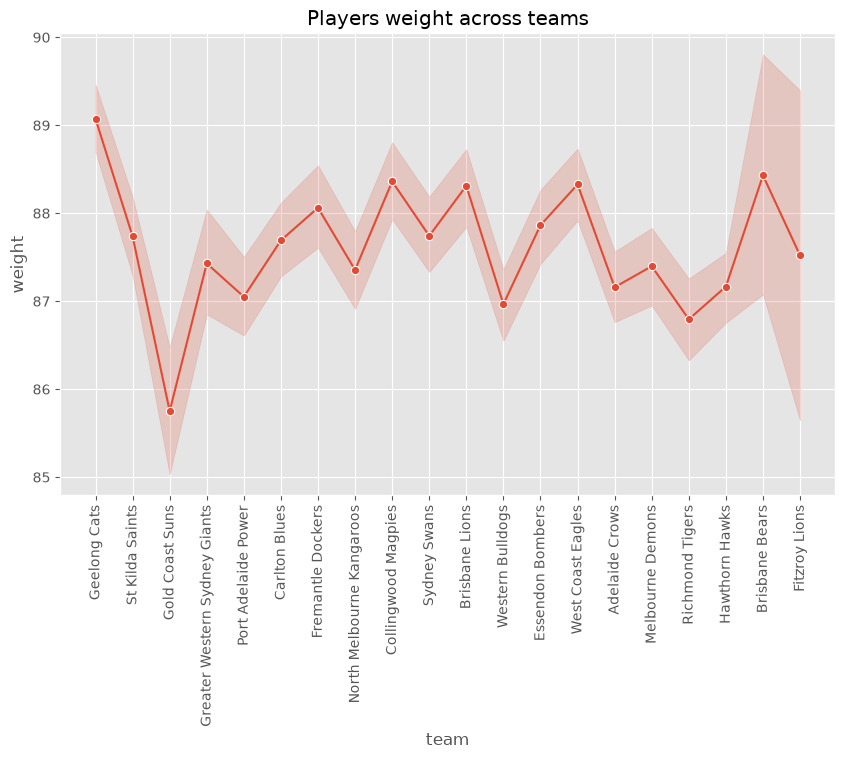

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(10, 6))
plt.title("Players weight across teams")
sns.lineplot(data=df, x='team', y='weight', marker='o')
plt.xticks(rotation=90)
plt.show()
plt.savefig('exported_charts/PLayers_weight across teams.png')

#### Observation:
- Geelong Cats players have the most weights close to 89 compare to others.
- While every other team crosses the mark of 87 Gold Cost Sun fall beneath it with the marginally low average weight.

#### Insight:
-  This information can be useful for recruitment, allowing teams to target players whose physical attributes align with their stratgic needs

### Q> Which teams have the highest average fantasy points combined?

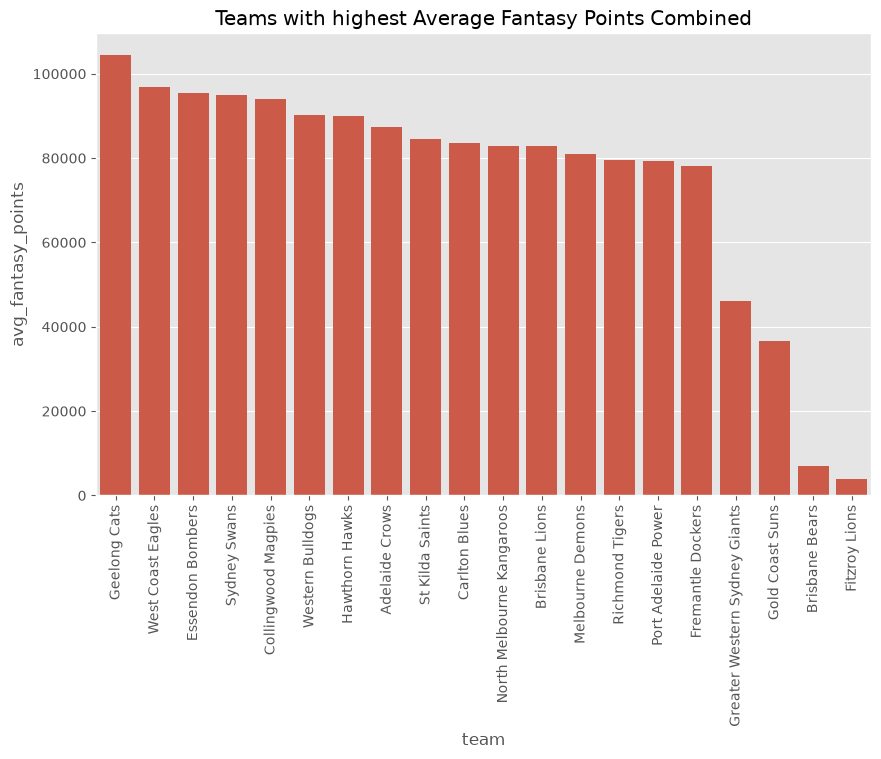

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(10, 6))
plt.title("Teams with highest Average Fantasy Points Combined")
team_with_high_fantasy_points = df.groupby('team')['avg_fantasy_points'].sum().sort_values(ascending=False)
sns.barplot(data=team_with_high_fantasy_points)
plt.xticks(rotation=90)
plt.show()
plt.savefig('exported_charts/teams with highest average points.png')


#### Observation:
- From the observation int he above charts it can be seen Geelong Cats have been dominant in every aspect, with highest fantasy score it shows CAts performance is at peak
- On the contrary, Fritz lions and Brisbane Bears have the lowest of fantasy score indicating the were not performing well accordingly

#### Insight:
- Teams with higher average fantasy points are likely to be more popular among fantasy football users. These teams can attract more attention from fans, making them useful for promotions and content creation.

### Q> Who are the Top 15 goal scorers?


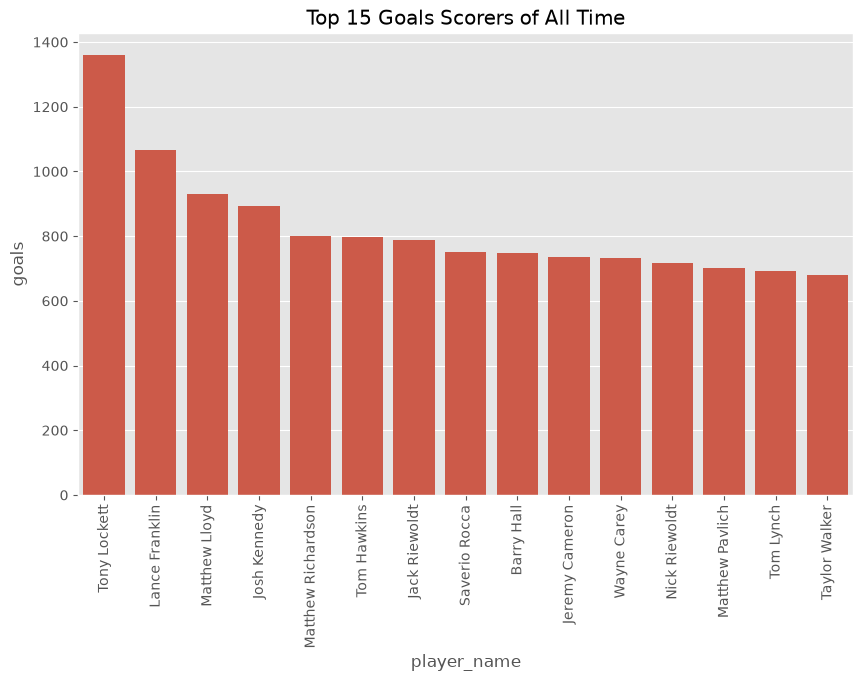

<Figure size 640x480 with 0 Axes>

In [9]:
plt.figure(figsize=(10, 6))
plt.title("Top 15 Goals Scorers of All Time")
top_scorer = df.groupby('player_name')['goals'].sum().sort_values(ascending=False).head(15)
sns.barplot(data=top_scorer)
plt.xticks(rotation=90)
plt.show()
plt.savefig('exported_charts/Top 15 goal scorer.png')

#### Observation:
- Tony Lockett has the most score goals of all the time close to 1400.
- Others plays who appear in the top ten has goals close to 800.
- Lance Franklin other than tony locket is the only one that has crossed 1000 goals mark and is second to Tony.

#### Insights:
- This information can be used to recruit players based on their performance.
- Tony lockett can also become the face of social media or marketting based on goals he is likely to have big fan base.

### Q> How many records are available for each season?

C:\Users\MEE\AppData\Local\Temp\ipykernel_11896\1584017917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_counts.index.astype(int), y=season_counts.values, palette='viridis')


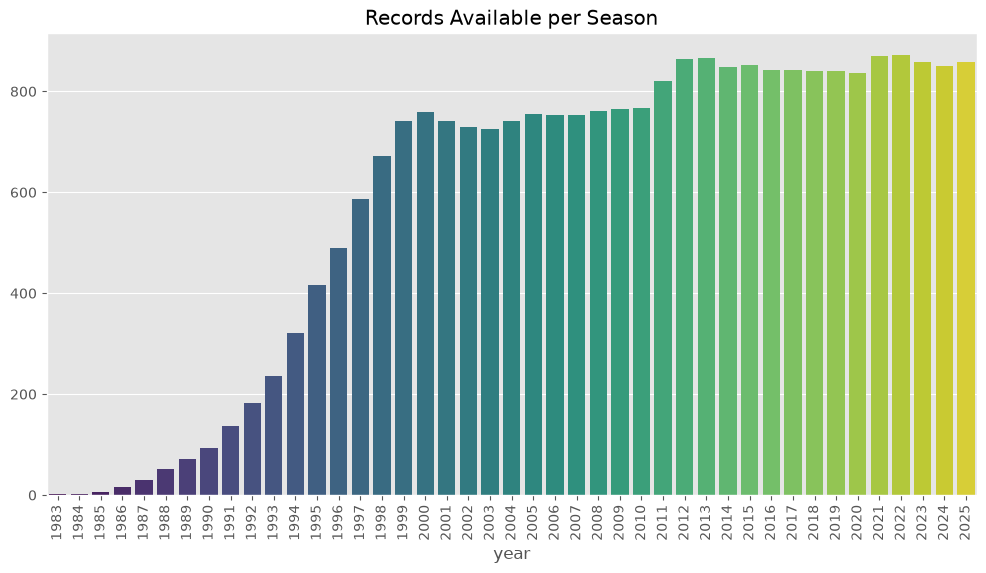

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize=(12, 6))
season_counts = df['year'].value_counts().sort_index()
sns.barplot(x=season_counts.index.astype(int), y=season_counts.values, palette='viridis')
plt.title("Records Available per Season")
plt.xticks(rotation=90)
plt.show()
plt.savefig('exported_charts/Season records.png')

#### Observation:
- From the graph it is clear that the trend has gone quite uphill with a significant increase from the early 1980s to early 2000s.
-The peak record was maintained in 2012 and 2013.

#### Insight:
- The continuous increase in data records over time suggests a growing interest in data collection and analytics within the league. This trend provides a more comprehensive dataset for advanced statistical analysis, predictive analysis and decision making in recent years.

#### 5 Key Insights:

- Geelong Cats consistently demonstrate high performance, leading in games played, player count, average player weight, and combined average fantasy points, indicating a successful franchise.
- The majority of players tend to retire between the ages of 27 and 33, providing valuable data for contract negotiations and career planning.
- Player weight varies across teams, with Geelong Cats players having a higher average. This suggests that physical attributes are a strategic consideration in team recruitment.
- High performing players and teams, such as Tony Lockett as a top goal scorer and Geelong Cats with high fantasy points, can be leveraged for marketing and fan engagement due to their popularity and consistent output.
- The significant increase in available records per season, especially from the early 1980s to the early 2000s and peaking in 2012-2013, indicates a growing emphasis on data collection.